# Paper Results Explorer

Diagnostic notebook for manually reviewing DUNE paper evidence, comparing promoted model results, and planning controlled parameter sweeps. It reads the promoted artifacts under `experiments/*/results/` and `experiments/publication/paper-artifacts/` by default; it does not rerun full experiments unless you explicitly opt in.


## tl;dr

Run the setup and summary cells first. The notebook then surfaces:

- which promoted artifacts currently back each paper claim;
- benchmark NLL, CRPS, and calibration behavior by dataset and model;
- per-family epistemic-band calibration for the simulation claims;
- VI-versus-NUTS band-width diagnostics;
- the current config knobs that are most worth tuning manually.

The optional sweep section is intentionally off by default so that opening the notebook never launches expensive training runs.


## Context & Methods

### Key Assumptions

- Promoted `results/` directories are the source of truth for paper-facing claims; scratch `runs/` output must be inspected and promoted before it should influence the manuscript.
- Lower NLL and CRPS are better. Lower calibration error is better, but it is not a complete uncertainty-quality metric by itself.
- Effect-ribbon calibration summarizes epistemic uncertainty in centered shape functions, while response-level benchmark metrics include both epistemic and aleatoric behavior through the response family.
- Full canonical experiment reruns are manual and can be slow. Use smoke commands for contract checks, then promote only deliberately reviewed full runs.


## Setup

Load lightweight analysis dependencies and locate the repository root. If this cell fails, run the notebook from the repository root with `uv run --extra experiments jupyter lab` or equivalent.


In [1]:
from __future__ import annotations

import json
import math
import shlex
from collections.abc import Mapping
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not find repository root from current working directory.")


REPO_ROOT = find_repo_root()
EXPERIMENTS = REPO_ROOT / "experiments"
PUBLICATION = EXPERIMENTS / "publication"
PAPER_ARTIFACTS = PUBLICATION / "paper-artifacts"
PAPER_TABLES = PAPER_ARTIFACTS / "tables"

print(f"Repository root: {REPO_ROOT}")
print(f"Paper tables:     {PAPER_TABLES}")


Repository root: /Users/entropy/Git/dune-bayes
Paper tables:     /Users/entropy/Git/dune-bayes/experiments/publication/paper-artifacts/tables


### Parameters

Change these values while exploring. The default mode reads promoted canonical outputs only.


In [2]:
USE_CANONICAL_RESULTS = True
SELECTED_DATASETS: list[str] | None = None  # Example: ["autompg", "naval"]
SELECTED_MODELS: list[str] | None = None    # Example: ["dune_bayes", "plain_mlp"]
N_TOP_ROWS = 20
RUN_LOCAL_SWEEP = False
SWEEP_OUTPUT_ROOT = EXPERIMENTS / "publication" / "runs" / "manual-sweeps"


## Data

Load publication provenance, the evidence summary table, and helper functions for canonical metric tables.


In [3]:
def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def read_yaml(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def flatten_mapping(data: Mapping, prefix: str = "") -> dict[str, object]:
    flattened: dict[str, object] = {}
    for key, value in data.items():
        name = f"{prefix}.{key}" if prefix else str(key)
        if isinstance(value, Mapping):
            flattened.update(flatten_mapping(value, name))
        else:
            flattened[name] = value
    return flattened


def load_csv(path: Path, **columns: object) -> pd.DataFrame:
    frame = pd.read_csv(path)
    for name, value in columns.items():
        frame[name] = value
    return frame


provenance = read_json(PAPER_ARTIFACTS / "provenance.json")
evidence_summary = pd.read_csv(PAPER_TABLES / "evidence-summary.csv")

snapshot = pd.DataFrame(provenance["inputs"])
display(Markdown(f"Publication artifacts generated at `{provenance['generated_at']}` with builder `{provenance['builder_version']}`."))
display(evidence_summary)


Publication artifacts generated at `2026-06-27T09:43:43+00:00` with builder `0.1.0.dev0`.

,claim_id,family,requires,artifact_class,path,experiment,seed
0,central-disentanglement,disentanglement,full,simulation,experiments/disentanglement/results/canonical,disentanglement,9901
1,per-feature-per-parameter-epistemic-bands,epistemic_bands,full,simulation,experiments/parameter_recovery/results/canonic...,parameter_recovery_normal,9801
2,per-feature-per-parameter-epistemic-bands,epistemic_bands,full,simulation,experiments/parameter_recovery/results/canonic...,parameter_recovery_student_t,9802
3,per-feature-per-parameter-epistemic-bands,epistemic_bands,full,simulation,experiments/parameter_recovery/results/canonic...,parameter_recovery_gamma,9803
4,per-feature-per-parameter-epistemic-bands,epistemic_bands,full,simulation,experiments/jsu_showcase/results/canonical,jsu_showcase,10001
5,vi-vs-nuts-limitation,vi_vs_nuts_limitation,full,validation,experiments/hmc_agreement/results/canonical,hmc_agreement,101
6,benchmark-comparator-panel,benchmark_comparator,full,real_data_benchmark,experiments/uci_benchmark/results/canonical,uci_benchmark,102


### Config Inventory

This table shows the current promoted experiment knobs. Use it to decide which parameter should be varied next instead of guessing from memory.


In [4]:
config_rows = []
for config_path in sorted(EXPERIMENTS.glob("*/results/*/config.yaml")):
    config = read_yaml(config_path)
    run_json = read_json(config_path.with_name("run.json")) if config_path.with_name("run.json").exists() else {}
    row = {
        "result_path": str(config_path.parent.relative_to(REPO_ROOT)),
        "experiment": config.get("experiment"),
        "seed": run_json.get("seed", config.get("seed")),
        "smoke": run_json.get("smoke"),
    }
    flattened = flatten_mapping(config)
    for key in (
        "family",
        "draws",
        "predictive_samples",
        "architecture.hidden_dims",
        "architecture.prior_scale",
        "architecture.activation",
        "training.epochs",
        "training.learning_rate",
        "training.lr",
        "training.warmup_epochs",
        "data.n",
        "data.grid_size",
    ):
        row[key] = flattened.get(key)
    config_rows.append(row)

config_inventory = pd.DataFrame(config_rows)
display(config_inventory.sort_values(["experiment", "result_path"]).head(N_TOP_ROWS))


,result_path,experiment,seed,smoke,family,draws,predictive_samples,architecture.hidden_dims,architecture.prior_scale,architecture.activation,training.epochs,training.learning_rate,training.lr,training.warmup_epochs,data.n,data.grid_size
0,experiments/disentanglement/results/canonical,disentanglement,9901,False,normal,500.0,NaN,"[32, 32]",1.0,tanh,800,0.010,NaN,40.0,384.0,200.0
1,experiments/hmc_agreement/results/canonical,hmc_agreement,101,False,normal,NaN,NaN,[],1.0,None,10000,NaN,0.003,500.0,96.0,NaN
2,experiments/jsu_showcase/results/canonical,jsu_showcase,10001,False,johnson_su,500.0,NaN,"[32, 32]",1.0,tanh,2500,0.003,NaN,100.0,1024.0,200.0
3,experiments/parameter_recovery/results/canonic...,parameter_recovery_gamma,9803,False,gamma,500.0,NaN,"[32, 32]",1.0,tanh,800,0.010,NaN,40.0,256.0,NaN
4,experiments/parameter_recovery/results/canonic...,parameter_recovery_normal,9801,False,normal,500.0,NaN,"[32, 32]",1.0,tanh,800,0.010,NaN,40.0,256.0,NaN
5,experiments/parameter_recovery/results/canonic...,parameter_recovery_student_t,9802,False,student_t,500.0,NaN,"[32, 32]",1.0,tanh,800,0.010,NaN,40.0,256.0,NaN
6,experiments/uci_benchmark/results/canonical,uci_benchmark,102,False,None,500.0,500.0,[16],1.0,tanh,250,0.010,NaN,20.0,NaN,NaN
7,experiments/uci_benchmark/results/namlss-smoke,uci_benchmark,102,True,None,500.0,500.0,[16],1.0,tanh,250,0.010,NaN,20.0,NaN,NaN
8,experiments/uci_benchmark/results/smoke,uci_benchmark,102,True,None,500.0,500.0,[16],1.0,tanh,250,0.010,NaN,20.0,NaN,NaN
9,experiments/walking_skeleton/results/canonical,walking_skeleton,97,False,normal,256.0,NaN,[8],NaN,None,20,NaN,NaN,NaN,100.0,NaN


## Results 1 - Benchmark Panel

Review the real-data benchmark comparison. The plots are for triage: they should point you toward datasets or model classes worth inspecting in detail, not replace dataset-specific judgment.


In [5]:
comparison_path = EXPERIMENTS / "uci_benchmark" / "results" / "canonical" / "metrics" / "comparison.csv"
comparison = pd.read_csv(comparison_path)

if SELECTED_DATASETS is not None:
    comparison = comparison[comparison["dataset"].isin(SELECTED_DATASETS)]
if SELECTED_MODELS is not None:
    comparison = comparison[comparison["model"].isin(SELECTED_MODELS)]

for metric in ("mean_nll", "mean_crps", "calibration_error"):
    comparison[f"rank_{metric}"] = comparison.groupby("dataset")[metric].rank(method="min", ascending=True)

best_rows = []
for metric in ("mean_nll", "mean_crps", "calibration_error"):
    subset = comparison.dropna(subset=[metric]).copy()
    if not subset.empty:
        winners = subset.loc[subset.groupby("dataset")[metric].idxmin(), ["dataset", "model", metric]]
        winners = winners.rename(columns={"model": f"best_{metric}_model", metric: f"best_{metric}"})
        best_rows.append(winners.set_index("dataset"))

benchmark_winners = pd.concat(best_rows, axis=1).reset_index() if best_rows else pd.DataFrame()
display(comparison.sort_values(["dataset", "rank_mean_nll", "rank_mean_crps"]).head(N_TOP_ROWS))
display(Markdown("### Per-dataset winners"))
display(benchmark_winners)


,dataset,family,model,uncertainty_scope,n_test,mean_nll,mean_crps,calibration_error,rank_mean_nll,rank_mean_crps,rank_calibration_error
3,autompg,gaussian_residual_mixture,deep_ensemble,predictive_only,78,2.386182,1.446779,0.023077,1.0,1.0,1.0
2,autompg,gaussian_residual,plain_mlp,predictive_only,78,2.460731,1.534288,0.024103,2.0,2.0,2.0
0,autompg,normal,dune_bayes,distributional_parameter_bands,78,5.430565,12.118775,0.160000,3.0,4.0,4.0
1,autompg,normal_homoscedastic,BayesNAM-style (our implementation),mean_only_variational_location,78,7.023231,2.307063,0.095897,4.0,3.0,3.0
38,bike,gaussian_residual,plain_mlp,predictive_only,3476,6.429072,81.366478,0.033107,1.0,1.0,1.0
39,bike,gaussian_residual_mixture,deep_ensemble,predictive_only,3476,6.429581,81.488809,0.033510,2.0,2.0,2.0
36,bike,negative_binomial,dune_bayes,distributional_parameter_bands,3476,8.347713,172.368492,0.140150,3.0,4.0,3.0
37,bike,normal_homoscedastic,BayesNAM-style (our implementation),mean_only_variational_location,3476,7616.728054,128.800294,0.157296,4.0,3.0,4.0
7,concrete,gaussian_residual_mixture,deep_ensemble,predictive_only,206,3.105517,3.018431,0.015534,1.0,1.0,2.0
6,concrete,gaussian_residual,plain_mlp,predictive_only,206,3.128797,3.019990,0.012621,2.0,2.0,1.0


### Per-dataset winners

,dataset,best_mean_nll_model,best_mean_nll,best_mean_crps_model,best_mean_crps,best_calibration_error_model,best_calibration_error
0,autompg,deep_ensemble,2.386182,deep_ensemble,1.446779,deep_ensemble,0.023077
1,bike,plain_mlp,6.429072,plain_mlp,81.366478,plain_mlp,0.033107
2,concrete,deep_ensemble,3.105517,deep_ensemble,3.018431,plain_mlp,0.012621
3,energy,deep_ensemble,2.132162,deep_ensemble,1.091814,deep_ensemble,0.029351
4,kin8nm,deep_ensemble,-0.965112,deep_ensemble,0.050931,plain_mlp,0.007033
5,naval,deep_ensemble,-3.862733,plain_mlp,0.002798,plain_mlp,0.021265
6,power,plain_mlp,2.837787,plain_mlp,2.289024,plain_mlp,0.007252
7,protein,deep_ensemble,2.974630,deep_ensemble,2.687422,plain_mlp,0.014839
8,wine,deep_ensemble,0.961386,deep_ensemble,0.346816,deep_ensemble,0.011250
9,yacht,plain_mlp,1.732603,plain_mlp,0.687180,deep_ensemble,0.036129


/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_63919/2637714337.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=order, vert=False)
/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_63919/2637714337.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=order, vert=False)
/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_63919/2637714337.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=order, vert=False)


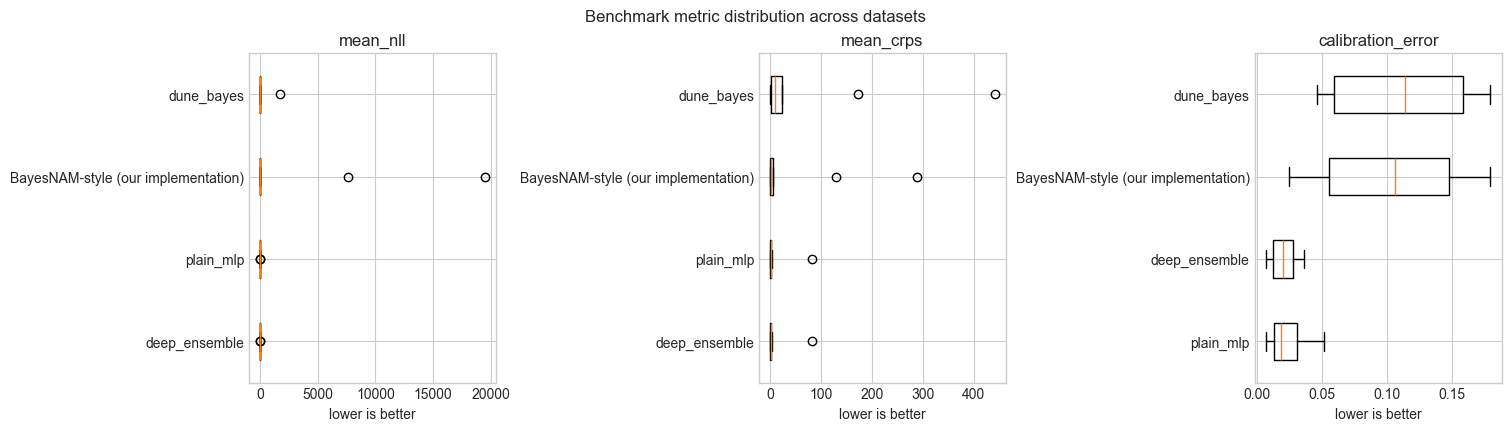

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
metrics = ["mean_nll", "mean_crps", "calibration_error"]
for axis, metric in zip(axes, metrics, strict=True):
    plot_data = comparison.dropna(subset=[metric]).copy()
    order = plot_data.groupby("model")[metric].median().sort_values().index
    values = [plot_data.loc[plot_data["model"] == model, metric].to_numpy() for model in order]
    axis.boxplot(values, labels=order, vert=False)
    axis.set_title(metric)
    axis.set_xlabel("lower is better")
fig.suptitle("Benchmark metric distribution across datasets")
plt.show()


### Dataset Deep Dive

Pick a dataset above and inspect its NLL, CRPS, calibration, and variance split tables. This is where odd benchmark behavior usually becomes understandable.


In [7]:
DATASET_TO_INSPECT = "autompg"
DATASET_METRIC_DIR = EXPERIMENTS / "uci_benchmark" / "results" / "canonical" / "metrics" / DATASET_TO_INSPECT

metric_tables = {}
for metric_file in sorted(DATASET_METRIC_DIR.glob("*.csv")):
    metric_tables[metric_file.stem] = pd.read_csv(metric_file)
    display(Markdown(f"#### {DATASET_TO_INSPECT}: `{metric_file.name}`"))
    display(metric_tables[metric_file.stem].head(N_TOP_ROWS))

variance_split = metric_tables.get("variance_split")
if variance_split is not None and {"aleatoric", "epistemic", "total"}.issubset(variance_split.columns):
    summary = variance_split[["aleatoric", "epistemic", "total"]].describe().T
    summary["epistemic_share_mean"] = (variance_split["epistemic"] / variance_split["total"]).mean()
    display(Markdown("#### Variance split summary"))
    display(summary)


#### autompg: `calibration.csv`

,dataset,bin_lower,bin_upper,count,fraction,expected_fraction
0,autompg,0.0,0.1,0,0.000000,0.1
1,autompg,0.1,0.2,0,0.000000,0.1
2,autompg,0.2,0.3,0,0.000000,0.1
3,autompg,0.3,0.4,0,0.000000,0.1
4,autompg,0.4,0.5,0,0.000000,0.1
5,autompg,0.5,0.6,0,0.000000,0.1
6,autompg,0.6,0.7,0,0.000000,0.1
7,autompg,0.7,0.8,0,0.000000,0.1
8,autompg,0.8,0.9,8,0.102564,0.1
9,autompg,0.9,1.0,70,0.897436,0.1


#### autompg: `crps.csv`

,dataset,family,model,n_test,mean_crps
0,autompg,normal,dune_bayes,78,12.118775


#### autompg: `nll.csv`

...

,dataset,model,observation,parameter,q05,q50,q95
0,autompg,dune_bayes,0,loc,5.616308,7.107835,8.723894
1,autompg,dune_bayes,1,loc,6.019692,7.546660,9.158796
2,autompg,dune_bayes,2,loc,5.545571,7.246342,9.014164
3,autompg,dune_bayes,3,loc,5.741457,7.101527,8.365697
4,autompg,dune_bayes,4,loc,6.043890,7.614690,9.114240
5,autompg,dune_bayes,5,loc,6.323231,7.756343,9.015334
6,autompg,dune_bayes,6,loc,5.840392,7.128740,8.404176
7,autompg,dune_bayes,7,loc,5.498341,6.933427,8.554373
8,autompg,dune_bayes,8,loc,5.285501,6.790081,8.560031
9,autompg,dune_bayes,9,loc,5.309120,6.774753,8.384510


#### autompg: `variance_split.csv`

,dataset,model,observation,aleatoric,epistemic,total
0,autompg,dune_bayes,0,25.100725,0.880804,25.981529
1,autompg,dune_bayes,1,25.661304,0.898698,26.560001
2,autompg,dune_bayes,2,18.432070,1.143042,19.575111
3,autompg,dune_bayes,3,39.108109,0.649887,39.757996
4,autompg,dune_bayes,4,52.955711,0.872847,53.828560
5,autompg,dune_bayes,5,44.707672,0.662719,45.370392
6,autompg,dune_bayes,6,38.588436,0.645743,39.234180
7,autompg,dune_bayes,7,27.498491,0.909670,28.408161
8,autompg,dune_bayes,8,26.903028,0.958047,27.861074
9,autompg,dune_bayes,9,27.937019,0.851033,28.788052


#### Variance split summary

,count,mean,std,min,25%,50%,75%,max,epistemic_share_mean
aleatoric,78.0,51.817619,16.395456,18.432070,40.172661,53.089310,65.119528,81.471619,0.017811
epistemic,78.0,0.803421,0.173842,0.535798,0.651229,0.806079,0.909413,1.219186,0.017811
total,78.0,52.621040,16.383009,19.575111,40.800377,53.828108,65.888792,82.581245,0.017811


## Results 2 - Epistemic Band Calibration

These are simulation checks for per-feature, per-parameter effect ribbons. The diagonal is ideal calibration; systematic under-coverage is a signal to inspect prior scale, epochs, architecture width, or the mean-field limitation before making stronger claims.


In [8]:
def calibration_sources() -> pd.DataFrame:
    frames = []
    for path in sorted((EXPERIMENTS / "parameter_recovery" / "results").glob("*/metrics/calibration.csv")):
        config = read_yaml(path.parents[1] / "config.yaml")
        frames.append(load_csv(path, experiment=config["experiment"], family=config["family"], source=str(path.relative_to(REPO_ROOT))))
    jsu_path = EXPERIMENTS / "jsu_showcase" / "results" / "canonical" / "metrics" / "coverage.csv"
    if jsu_path.exists():
        config = read_yaml(jsu_path.parents[1] / "config.yaml")
        frames.append(load_csv(jsu_path, experiment=config["experiment"], family=config["family"], source=str(jsu_path.relative_to(REPO_ROOT))))
    return pd.concat(frames, ignore_index=True)


calibration = calibration_sources()
calibration["abs_error"] = (calibration["empirical_coverage"] - calibration["nominal"]).abs()
calibration_summary = (
    calibration.groupby(["family", "parameter"], as_index=False)
    .agg(mean_abs_error=("abs_error", "mean"), max_abs_error=("abs_error", "max"), min_coverage=("empirical_coverage", "min"))
    .sort_values(["mean_abs_error", "max_abs_error"], ascending=False)
)

display(calibration.sort_values(["family", "parameter", "nominal"]))
display(Markdown("### Largest calibration gaps"))
display(calibration_summary.head(N_TOP_ROWS))


,parameter,nominal,empirical_coverage,experiment,family,source,abs_error
0,concentration,0.50,0.242188,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.257812
1,concentration,0.80,0.480469,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.319531
2,concentration,0.90,0.656250,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.243750
3,concentration,0.95,0.968750,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.018750
4,rate,0.50,0.386719,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.113281
5,rate,0.80,0.753906,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.046094
6,rate,0.90,0.839844,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.060156
7,rate,0.95,0.914062,parameter_recovery_gamma,gamma,experiments/parameter_recovery/results/canonic...,0.035937
36,loc,0.50,0.395000,jsu_showcase,johnson_su,experiments/jsu_showcase/results/canonical/met...,0.105000
37,loc,0.80,0.560000,jsu_showcase,johnson_su,experiments/jsu_showcase/results/canonical/met...,0.240000


### Largest calibration gaps

,family,parameter,mean_abs_error,max_abs_error,min_coverage
8,student_t,df,0.212500,0.500000,1.000000
0,gamma,concentration,0.209961,0.319531,0.242188
3,johnson_su,scale,0.208750,0.355000,0.145000
5,johnson_su,tail,0.206250,0.285000,0.265000
2,johnson_su,loc,0.161250,0.240000,0.395000
9,student_t,location,0.124023,0.190625,0.335938
6,normal,location,0.101758,0.167188,0.375000
7,normal,scale,0.100000,0.143750,0.367188
10,student_t,scale,0.088477,0.121094,0.621094
4,johnson_su,skew,0.082500,0.155000,0.345000


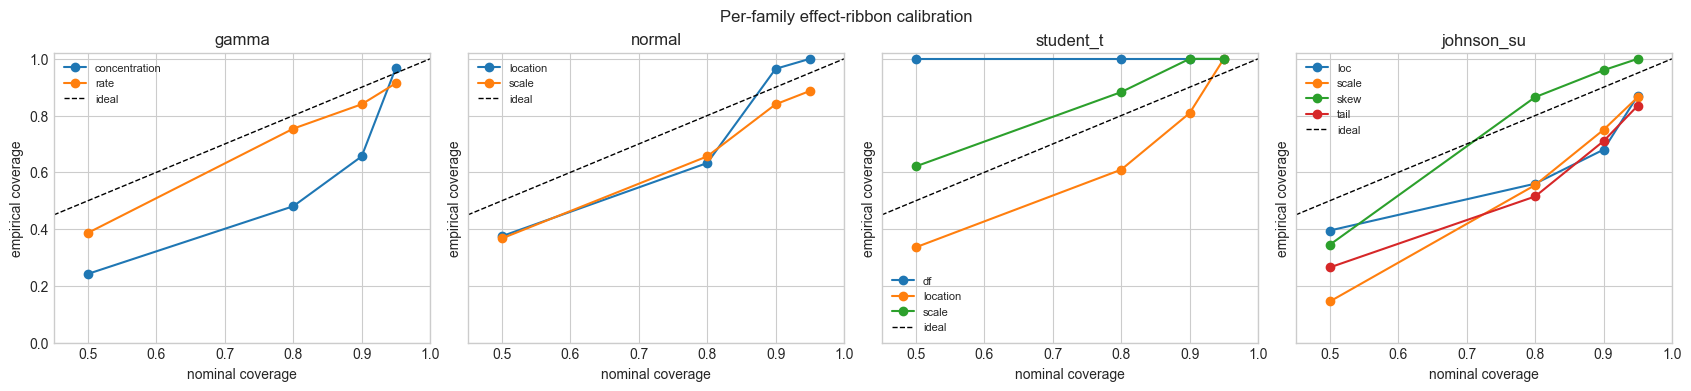

In [9]:
families = list(calibration["family"].drop_duplicates())
fig, axes = plt.subplots(1, len(families), figsize=(4.2 * len(families), 3.8), sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for axis, family in zip(axes, families, strict=True):
    subset = calibration[calibration["family"] == family]
    for parameter, parameter_frame in subset.groupby("parameter"):
        axis.plot(parameter_frame["nominal"], parameter_frame["empirical_coverage"], marker="o", label=parameter)
    axis.plot([0.45, 1.0], [0.45, 1.0], "k--", lw=1, label="ideal")
    axis.set_title(family)
    axis.set_xlabel("nominal coverage")
    axis.set_ylabel("empirical coverage")
    axis.set_xlim(0.45, 1.0)
    axis.set_ylim(0.0, 1.02)
    axis.legend(fontsize=8)
fig.suptitle("Per-family effect-ribbon calibration")
plt.show()


## Results 3 - Disentanglement Claim

The central simulation should show aleatoric uncertainty rising in the noisy dense region and epistemic uncertainty rising in the sparse region.


,value
aleatoric_dense,0.914613
aleatoric_dense_to_sparse_ratio,3.983027
aleatoric_sparse,0.229627
draws,500.000000
epistemic_dense,0.052425
epistemic_sparse,0.068977
epistemic_sparse_to_dense_ratio,1.315719
epochs,800.000000
final_loss,1.730117
n,384.000000


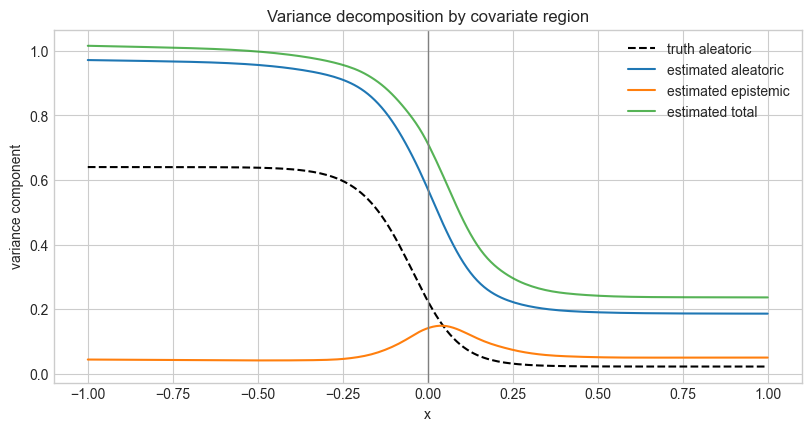

In [10]:
disentanglement_dir = EXPERIMENTS / "disentanglement" / "results" / "canonical"
regional_components = read_json(disentanglement_dir / "metrics" / "regional_components.json")
decomposition = np.load(disentanglement_dir / "arrays" / "decomposition.npz")

display(pd.Series(regional_components, name="value").to_frame())

fig, axis = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
grid = decomposition["grid"]
axis.plot(grid, decomposition["truth_aleatoric"], label="truth aleatoric", color="black", linestyle="--")
axis.plot(grid, decomposition["aleatoric"], label="estimated aleatoric")
axis.plot(grid, decomposition["epistemic"], label="estimated epistemic")
axis.plot(grid, decomposition["total"], label="estimated total", alpha=0.8)
axis.axvline(0.0, color="0.5", lw=1)
axis.set(title="Variance decomposition by covariate region", xlabel="x", ylabel="variance component")
axis.legend()
plt.show()


## Results 4 - VI Versus NUTS Limitation

This validation-only comparison is useful for deciding how strongly to phrase the uncertainty claims. Ratios below one mean VI bands are narrower than NUTS bands.


### NUTS diagnostics

,value
chains,4.000000
divergences,0.000000
ess_bulk_min,1330.424058
r_hat_max,1.003742
samples_per_chain,750.000000
warmup,750.000000


### Band-width ratios

,feature,distribution_parameter,median_vi_to_nuts_width_ratio,vi_inside_nuts_fraction,median_normalized_center_difference
0,x1,loc,0.411684,1.0,0.012786
1,x1,raw_scale,0.483940,1.0,0.023012
2,x2,loc,0.414983,1.0,0.026171
3,x2,raw_scale,0.456318,1.0,0.001710


### Parameter intervals

,parameter,vi_lower,vi_center,vi_upper,nuts_lower,nuts_center,nuts_upper
0,x1_weight[loc],0.869676,0.930082,0.990325,0.789207,0.933829,1.082269
1,x1_weight[raw_scale],-0.446231,-0.302507,-0.167410,-0.604497,-0.315765,-0.028350
2,x2_weight[loc],-0.550465,-0.482857,-0.419329,-0.648880,-0.491127,-0.332877
3,x2_weight[raw_scale],0.023436,0.159562,0.294905,-0.139115,0.160580,0.455795
4,intercept[loc],0.264084,0.337307,0.408035,0.252984,0.335816,0.415119
5,intercept[raw_scale],-0.674066,-0.531004,-0.384937,-0.697795,-0.550264,-0.376119


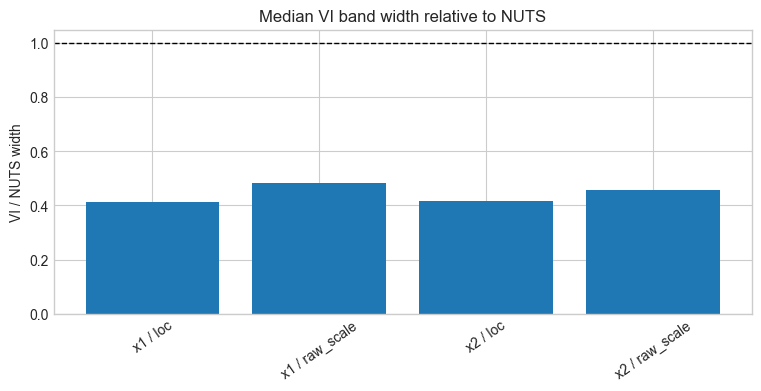

In [11]:
hmc_dir = EXPERIMENTS / "hmc_agreement" / "results" / "canonical"
band_width = pd.read_csv(hmc_dir / "metrics" / "band_width_ratios.csv")
parameter_intervals = pd.read_csv(hmc_dir / "metrics" / "parameter_intervals.csv")
diagnostics = read_json(hmc_dir / "metrics" / "diagnostics.json")

display(Markdown("### NUTS diagnostics"))
display(pd.Series(diagnostics, name="value").to_frame())
display(Markdown("### Band-width ratios"))
display(band_width)
display(Markdown("### Parameter intervals"))
display(parameter_intervals)

fig, axis = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
labels = band_width["feature"] + " / " + band_width["distribution_parameter"]
axis.bar(labels, band_width["median_vi_to_nuts_width_ratio"])
axis.axhline(1.0, color="black", linestyle="--", lw=1)
axis.set(title="Median VI band width relative to NUTS", ylabel="VI / NUTS width")
axis.tick_params(axis="x", rotation=35)
plt.show()


## Results 5 - Prior/Smoothness Sweep

This section is wired to the pre-registered Normal parameter-recovery sweep in `experiments/parameter_recovery/prior_sweep/`. It shows the exact smoke/full commands and, after you run candidates, summarizes calibration error and prior-scale diagnostics from ignored `runs/` artifacts.


In [12]:
PRIOR_SWEEP_CONFIG_DIR = EXPERIMENTS / "parameter_recovery" / "prior_sweep"
PRIOR_SWEEP_CONFIGS = sorted(PRIOR_SWEEP_CONFIG_DIR.glob("normal-*.yaml"))

def command_for_config(config_path: Path, *, smoke: bool) -> str:
    parts = [
        "uv",
        "run",
        "--extra",
        "experiments",
        "python",
        "experiments/parameter_recovery/run.py",
        str(config_path.relative_to(REPO_ROOT)),
    ]
    if smoke:
        parts.append("--smoke")
    return " ".join(shlex.quote(part) for part in parts)

prior_sweep_commands = pd.DataFrame(
    {
        "candidate": config_path.stem,
        "config": str(config_path.relative_to(REPO_ROOT)),
        "smoke_command": command_for_config(config_path, smoke=True),
        "full_command": command_for_config(config_path, smoke=False),
    }
    for config_path in PRIOR_SWEEP_CONFIGS
)

display(prior_sweep_commands)


,candidate,config,smoke_command,full_command
0,normal-empirical-bayes,experiments/parameter_recovery/prior_sweep/nor...,uv run --extra experiments python experiments/...,uv run --extra experiments python experiments/...
1,normal-fixed-0p3,experiments/parameter_recovery/prior_sweep/nor...,uv run --extra experiments python experiments/...,uv run --extra experiments python experiments/...
2,normal-fixed-1p0,experiments/parameter_recovery/prior_sweep/nor...,uv run --extra experiments python experiments/...,uv run --extra experiments python experiments/...
3,normal-fixed-3p0,experiments/parameter_recovery/prior_sweep/nor...,uv run --extra experiments python experiments/...,uv run --extra experiments python experiments/...
4,normal-hierarchical-ig,experiments/parameter_recovery/prior_sweep/nor...,uv run --extra experiments python experiments/...,uv run --extra experiments python experiments/...


In [13]:
def load_prior_sweep_results() -> pd.DataFrame:
    rows = []
    run_root = EXPERIMENTS / "parameter_recovery" / "runs" / "parameter_recovery_normal"
    for run_dir in sorted(run_root.glob("prior-sweep-normal-*")):
        calibration_path = run_dir / "metrics" / "calibration.csv"
        prior_path = run_dir / "metrics" / "prior_scale.json"
        config_path = run_dir / "config.yaml"
        if not calibration_path.exists() or not prior_path.exists() or not config_path.exists():
            continue
        calibration_frame = pd.read_csv(calibration_path)
        calibration_frame["abs_error"] = (calibration_frame["empirical_coverage"] - calibration_frame["nominal"]).abs()
        prior_state = read_json(prior_path)
        config = read_yaml(config_path)
        rows.append(
            {
                "candidate": run_dir.name,
                "prior": config["architecture"].get("prior", "fixed"),
                "configured_prior_scale": config["architecture"]["prior_scale"],
                "mean_abs_coverage_error": calibration_frame["abs_error"].mean(),
                "max_abs_coverage_error": calibration_frame["abs_error"].max(),
                "min_empirical_coverage": calibration_frame["empirical_coverage"].min(),
                "prior_mode": prior_state.get("mode"),
                "scale": prior_state.get("scale"),
                "scale_median": prior_state.get("scale_median"),
                "scale_mean": prior_state.get("scale_mean"),
                "run_path": str(run_dir.relative_to(REPO_ROOT)),
            }
        )
    return pd.DataFrame(rows)

prior_sweep_results = load_prior_sweep_results()
if prior_sweep_results.empty:
    display(Markdown("No prior-sweep runs found yet. Run one or more smoke/full commands above, then rerun this cell."))
else:
    display(prior_sweep_results.sort_values("mean_abs_coverage_error"))


,candidate,prior,configured_prior_scale,mean_abs_coverage_error,max_abs_coverage_error,min_empirical_coverage,prior_mode,scale,scale_median,scale_mean,run_path
0,prior-sweep-normal-fixed-0p3,fixed,0.3,0.658594,0.85625,0.0625,fixed,0.3,None,None,experiments/parameter_recovery/runs/parameter_...


### Confirmatory Seed Set

If a screening candidate beats the fixed `1.0` baseline, materialize baseline-versus-candidate configs for the pre-declared seeds `9801`, `9811`, and `9821`. Leave these runs in ignored `runs/` until all three seeds have been reviewed.


In [14]:
CONFIRMATORY_SEEDS = [9801, 9811, 9821]
CONFIRMATORY_CANDIDATE_CONFIG: Path | None = None
# Example after screening:
# CONFIRMATORY_CANDIDATE_CONFIG = PRIOR_SWEEP_CONFIG_DIR / "normal-empirical-bayes.yaml"


def materialize_confirmatory_configs(candidate_config: Path | None) -> pd.DataFrame:
    if candidate_config is None:
        return pd.DataFrame(
            columns=["candidate", "seed", "config", "smoke_command", "full_command"]
        )
    baseline_config = PRIOR_SWEEP_CONFIG_DIR / "normal-fixed-1p0.yaml"
    output_dir = EXPERIMENTS / "parameter_recovery" / "runs" / "confirmatory-configs"
    output_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for source_config in (baseline_config, candidate_config):
        base = read_yaml(source_config)
        label = source_config.stem
        for seed in CONFIRMATORY_SEEDS:
            config = dict(base)
            config["seed"] = seed
            config["artifacts"] = {
                "root": "../runs",
                "run_name": f"confirmatory-{label}-seed-{seed}",
            }
            target = output_dir / f"{label}-seed-{seed}.yaml"
            with target.open("w", encoding="utf-8") as handle:
                yaml.safe_dump(config, handle, sort_keys=False)
            rows.append(
                {
                    "candidate": label,
                    "seed": seed,
                    "config": str(target.relative_to(REPO_ROOT)),
                    "smoke_command": command_for_config(target, smoke=True),
                    "full_command": command_for_config(target, smoke=False),
                }
            )
    return pd.DataFrame(rows)


confirmatory_commands = materialize_confirmatory_configs(CONFIRMATORY_CANDIDATE_CONFIG)
if confirmatory_commands.empty:
    display(Markdown("Set `CONFIRMATORY_CANDIDATE_CONFIG` after the screening pass to generate confirmatory seed configs."))
else:
    display(confirmatory_commands)


Set `CONFIRMATORY_CANDIDATE_CONFIG` after the screening pass to generate confirmatory seed configs.

## Manual Optimization Workspace

Use this section to decide and track controlled follow-up runs. Keep the loop narrow: choose one claim family and one knob, run smoke mode first, run full output into ignored `runs/`, inspect the notebook and generated figures, then promote only deliberately reviewed results.


In [15]:
TUNING_KNOBS = pd.DataFrame(
    [
        {
            "knob": "architecture.prior_scale / architecture.prior",
            "why_it_matters": "Controls the ADR-0002 smoothness prior and is the first calibration-improvement branch.",
            "reasonable_probe_values": "pre-registered Normal sweep above",
            "watch_metrics": "coverage mean_abs_error, prior_scale.json, recovery ribbons",
        },
        {
            "knob": "architecture.hidden_dims",
            "why_it_matters": "Capacity knob; too small underfits effects, too wide can make VI optimization harder.",
            "reasonable_probe_values": "[16], [32, 32], [64, 64] after prior sweep",
            "watch_metrics": "NLL, CRPS, recovery RMSE from figures, calibration error",
        },
        {
            "knob": "training.epochs / warmup_epochs",
            "why_it_matters": "Separates optimization failure from model limitation.",
            "reasonable_probe_values": "0.5x, 1x, 2x current budget after prior sweep",
            "watch_metrics": "final loss, calibration gaps, visual ribbon stability",
        },
        {
            "knob": "draws / predictive_samples",
            "why_it_matters": "Reduces Monte Carlo noise in summaries without changing fitted parameters.",
            "reasonable_probe_values": "250, 500, 1000",
            "watch_metrics": "stability of intervals, NLL/CRPS standard error where available",
        },
        {
            "knob": "family choice",
            "why_it_matters": "Misspecified response families can dominate benchmark scores.",
            "reasonable_probe_values": "Normal vs StudentT; Beta for bounded targets; NegativeBinomial for counts",
            "watch_metrics": "PIT calibration, NLL, CRPS, residual figure patterns",
        },
    ]
)

display(TUNING_KNOBS)


,knob,why_it_matters,reasonable_probe_values,watch_metrics
0,architecture.prior_scale / architecture.prior,Controls the ADR-0002 smoothness prior and is ...,pre-registered Normal sweep above,"coverage mean_abs_error, prior_scale.json, rec..."
1,architecture.hidden_dims,"Capacity knob; too small underfits effects, to...","[16], [32, 32], [64, 64] after prior sweep","NLL, CRPS, recovery RMSE from figures, calibra..."
2,training.epochs / warmup_epochs,Separates optimization failure from model limi...,"0.5x, 1x, 2x current budget after prior sweep","final loss, calibration gaps, visual ribbon st..."
3,draws / predictive_samples,Reduces Monte Carlo noise in summaries without...,"250, 500, 1000","stability of intervals, NLL/CRPS standard erro..."
4,family choice,Misspecified response families can dominate be...,Normal vs StudentT; Beta for bounded targets; ...,"PIT calibration, NLL, CRPS, residual figure pa..."


In [16]:
if RUN_LOCAL_SWEEP:
    import subprocess

    for command in prior_sweep_commands["smoke_command"]:
        print(f"Running: {command}")
        subprocess.run(command, cwd=REPO_ROOT, shell=True, check=True)
else:
    display(Markdown("`RUN_LOCAL_SWEEP` is `False`, so no experiment commands were executed."))


`RUN_LOCAL_SWEEP` is `False`, so no experiment commands were executed.

## Takeaways

Use this generated summary as a starting point, then edit the markdown below after manual inspection. Do not promote a tuning result into the paper story until the corresponding artifact has been reviewed and promoted from `runs/` into `results/`.


In [17]:
summary_lines = []
if not benchmark_winners.empty:
    dune_best_nll = (benchmark_winners.get("best_mean_nll_model") == "dune_bayes").sum()
    summary_lines.append(f"- DUNE has the best NLL on {dune_best_nll} of {len(benchmark_winners)} benchmark datasets in the current comparison table.")
worst_calibration = calibration_summary.iloc[0]
summary_lines.append(
    "- Largest effect-ribbon calibration gap: "
    f"{worst_calibration['family']} / {worst_calibration['parameter']} "
    f"with mean absolute gap {worst_calibration['mean_abs_error']:.3f}."
)
summary_lines.append(
    "- Disentanglement ratios: aleatoric dense/sparse = "
    f"{regional_components['aleatoric_dense_to_sparse_ratio']:.2f}; "
    "epistemic sparse/dense = "
    f"{regional_components['epistemic_sparse_to_dense_ratio']:.2f}."
)
summary_lines.append(
    "- Median VI/NUTS width ratio range: "
    f"{band_width['median_vi_to_nuts_width_ratio'].min():.2f} to "
    f"{band_width['median_vi_to_nuts_width_ratio'].max():.2f}."
)

display(Markdown("\n".join(summary_lines)))


- DUNE has the best NLL on 0 of 10 benchmark datasets in the current comparison table.
- Largest effect-ribbon calibration gap: student_t / df with mean absolute gap 0.212.
- Disentanglement ratios: aleatoric dense/sparse = 3.98; epistemic sparse/dense = 1.32.
- Median VI/NUTS width ratio range: 0.41 to 0.48.

### Manual Notes

- Candidate claim to strengthen:
- Dataset or simulation to inspect next:
- Parameter change to try first:
- Acceptance bar before promotion:
- Manuscript caveat or wording change:
